In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

patients = pd.read_csv(r'C:\Users\malaa\Downloads\patients_clean.csv')
print("Loaded:", patients.shape)

Loaded: (111, 35)


In [2]:
def recommend_programmes(patient_row):
    recs = []
    
    income  = patient_row['Monthly Income JD']
    stage   = patient_row['CancerStageNum']
    zakat   = patient_row['Zakat Eligible'] == 'Yes'
    insured = patient_row['Insurance Type'] != 'Uninsured'
    psycho  = patient_row['Psychosocial Support Needed'] == 'Yes'
    equip   = patient_row['Equipment Needed'] != 'None'
    gov     = patient_row['Governorate']

    if income < 500:
        recs.append(('Goodwill Fund', 0.90))
    if zakat and income < 400:
        recs.append(('Zakat Fund', 0.95))
    if gov not in ['Amman']:
        recs.append(('Transportation Allowance', 0.80))
    if not insured and stage >= 2:
        recs.append(('Cancer Care Insurance', 0.88))
    if stage >= 3 and equip:
        recs.append(('Medical Equipment Programme', 0.85))
    if psycho:
        recs.append(('Psychosocial Support', 0.75))

    recs.sort(key=lambda x: x[1], reverse=True)
    return recs if recs else [('Goodwill Fund', 0.50)]

print("Recommender function ready!")

Recommender function ready!


In [3]:
patients['RecommendedProgrammes'] = patients.apply(
    recommend_programmes, axis=1
)
patients['TopRecommendation'] = patients['RecommendedProgrammes'].apply(
    lambda x: x[0][0]
)
patients['NumRecommendations'] = patients['RecommendedProgrammes'].apply(
    lambda x: len(x)
)

print("Top recommendation distribution:")
print(patients['TopRecommendation'].value_counts())

Top recommendation distribution:
TopRecommendation
Zakat Fund                     70
Goodwill Fund                  25
Medical Equipment Programme     7
Transportation Allowance        7
Psychosocial Support            2
Name: count, dtype: int64


In [4]:
covered  = (patients['NumRecommendations'] > 0).sum()
coverage = covered / len(patients) * 100
print(f"Patient Coverage : {coverage:.1f}%")
print(f"Target           : 100%")
print(f"Status           : {'PASS ✓' if coverage == 100 else 'NEEDS REVIEW'}")

Patient Coverage : 100.0%
Target           : 100%
Status           : PASS ✓


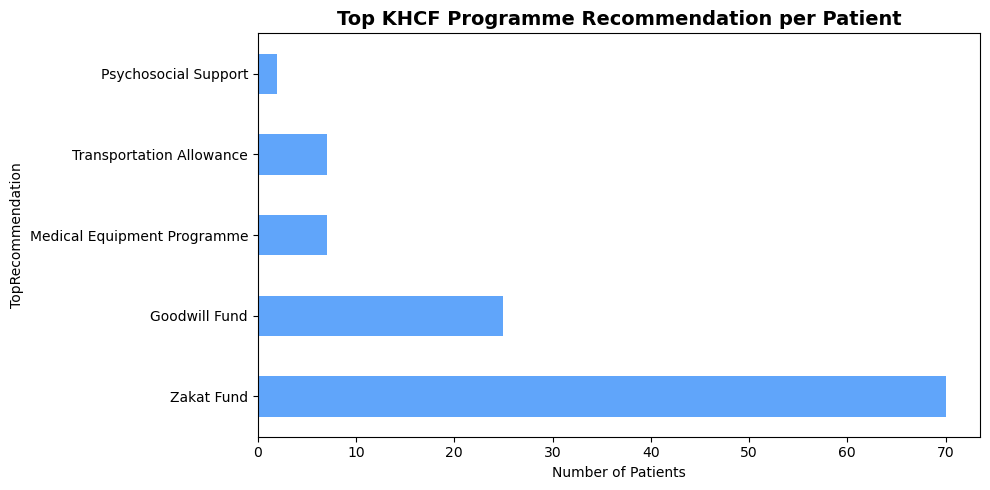

In [5]:
top = patients['TopRecommendation'].value_counts()

plt.figure(figsize=(10, 5))
top.plot(kind='barh', color='#60A5FA')
plt.title('Top KHCF Programme Recommendation per Patient',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Patients')
plt.tight_layout()
plt.savefig(r'C:\Users\malaa\Downloads\recommender_output.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Demo for first patient
p = patients.iloc[0]
recs = recommend_programmes(p)

print(f"Patient  : {p['Full Name']}")
print(f"Cancer   : {p['Cancer Type']} — {p['Cancer Stage']}")
print(f"Income   : {p['Monthly Income JD']} JD")
print(f"Insurance: {p['Insurance Type']}")
print(f"Zakat    : {p['Zakat Eligible']}")
print()
print("Recommended Programmes:")
for prog, score in recs:
    print(f"  ✓ {prog}  (confidence: {score:.0%})")

Patient  : Lina Ababneh
Cancer   : Breast Cancer — Stage III
Income   : 200 JD
Insurance: Uninsured
Zakat    : Yes

Recommended Programmes:
  ✓ Zakat Fund  (confidence: 95%)
  ✓ Goodwill Fund  (confidence: 90%)
  ✓ Cancer Care Insurance  (confidence: 88%)
  ✓ Medical Equipment Programme  (confidence: 85%)
  ✓ Transportation Allowance  (confidence: 80%)
  ✓ Psychosocial Support  (confidence: 75%)


In [7]:
patients.to_csv(r'C:\Users\malaa\Downloads\patients_with_recs.csv',
                index=False)
print("✓ Saved patients with recommendations")

✓ Saved patients with recommendations
